<img src="https://www.collinsdictionary.com/images/full/xray_560923156_1000.jpg" width="620" height="360" align="center"/>

<br>
<h1 style = "font-size:30px; font-weight : bold; color : blue; text-align: center; border-radius: 10px 15px;">Chest X-Ray (Pneumonia): Image Classification w/Convolutional Neural Networks and Transfer Learning</h1>
<br>

---

# Overview

The goal of this notebook is to use Convolutional Neural Networks on Chest X-Ray images to determine which samples are from patients with Pneumonia. In this dataset (version 3), there is one folder representing the train set and another one for the test set. The train folder is later split in the notebook into train/validation sets.

I use three different approaches for image classification: 1) A simple CNN, 2) Transfer Learning, using a pretrained model with frozen layers as the base for feature extraction and 3) Fine Tuning, unfreezing the last layers of the pretrained model.

Note: I’m using the third version of the Chest X-Ray dataset [(link)](https://www.kaggle.com/tolgadincer/labeled-chest-xray-images)

# <a id='0'>Content</a>
​
- <a href='#1'>Dataset Information</a>  
- <a href='#2'>Importing Packages and Dataset</a>  
- <a href='#3'>Exploring the Data</a>  
- <a href='#4'>Preparing the Data</a>
- <a href='#5'>Custom Model</a>
- <a href='#6'>Transfer Learning</a>
- <a href='#7'>Fine Tuning</a>
- <a href='#8'>Performance Metrics</a>
- <a href='#9'>References</a>

# <a id="1">Dataset Information</a> 

This dataset contains 5,856 validated Chest X-Ray images. The images are split into a training set and a testing set of independent patients. Images are labeled as (disease:NORMAL/BACTERIA/VIRUS)-(randomized patient ID)-(image number of a patient).

Chest X-ray images (anterior-posterior) were selected from retrospective cohorts of pediatric patients of one to five years old from Guangzhou Women and Children’s Medical Center, Guangzhou. All chest X-ray imaging was performed as part of patients’ routine clinical care.

For the analysis of chest x-ray images, all chest radiographs were initially screened for quality control by removing all low quality or unreadable scans. The diagnoses for the images were then graded by two expert physicians before being cleared for training the AI system. In order to account for any grading errors, the evaluation set was also checked by a third expert.

## <center> If you find this notebook useful, support with an upvote! <center>

# <a id="2">Importing Packages and Dataset</a> 

In [4]:
%pip install numpy==1.26.4 tensorflow==2.15.0 keras==2.15.0 opencv-python

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip available: 22.3.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [5]:
import pandas as pd       
import matplotlib as mat
import matplotlib.pyplot as plt    
import numpy as np
import seaborn as sns
%matplotlib inline

pd.options.display.max_colwidth = 100

import random
import os

from numpy.random import seed
seed(42)

random.seed(42)
os.environ['PYTHONHASHSEED'] = str(42)
os.environ['TF_DETERMINISTIC_OPS'] = '1'

from sklearn.model_selection import train_test_split
from sklearn import metrics
from sklearn.metrics import accuracy_score

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras import callbacks
from tensorflow.keras.models import Model
from tensorflow.keras.preprocessing.image import ImageDataGenerator

import glob
import cv2

from tensorflow.random import set_seed
set_seed(42)

import warnings
warnings.filterwarnings('ignore')

In [6]:
IMG_SIZE = 224
BATCH = 32
SEED = 42

In [7]:
import os
import glob

main_path = r"C:\Users\el_bostan\Desktop\X_Ray Image\chest_xray"

train_path = os.path.join(main_path, "train")
test_path = os.path.join(main_path, "test")

train_normal = glob.glob(train_path + "/NORMAL/*.jpeg")
train_pneumonia = glob.glob(train_path + "/PNEUMONIA/*.jpeg")

test_normal = glob.glob(test_path + "/NORMAL/*.jpeg")
test_pneumonia = glob.glob(test_path + "/PNEUMONIA/*.jpeg")

print(f"Train Normal: {len(train_normal)}")
print(f"Train Pneumonia: {len(train_pneumonia)}")
print(f"Test Normal: {len(test_normal)}")
print(f"Test Pneumonia: {len(test_pneumonia)}")

Train Normal: 1349
Train Pneumonia: 3883
Test Normal: 234
Test Pneumonia: 390


In [8]:
train_list = [x for x in train_normal]
train_list.extend([x for x in train_pneumonia])

df_train = pd.DataFrame(np.concatenate([['Normal']*len(train_normal) , ['Pneumonia']*len(train_pneumonia)]), columns = ['class'])
df_train['image'] = [x for x in train_list]

test_list = [x for x in test_normal]
test_list.extend([x for x in test_pneumonia])

df_test = pd.DataFrame(np.concatenate([['Normal']*len(test_normal) , ['Pneumonia']*len(test_pneumonia)]), columns = ['class'])
df_test['image'] = [x for x in test_list]

In [9]:
df_train

,class,image
0,Normal,C:\Users\el_bostan\Desktop\X_Ray Image\chest_xray\train/NORMAL\NORMAL-1003233-0001.jpeg
1,Normal,C:\Users\el_bostan\Desktop\X_Ray Image\chest_xray\train/NORMAL\NORMAL-1012843-0001.jpeg
2,Normal,C:\Users\el_bostan\Desktop\X_Ray Image\chest_xray\train/NORMAL\NORMAL-1014768-0001.jpeg
3,Normal,C:\Users\el_bostan\Desktop\X_Ray Image\chest_xray\train/NORMAL\NORMAL-1023731-0001.jpeg
4,Normal,C:\Users\el_bostan\Desktop\X_Ray Image\chest_xray\train/NORMAL\NORMAL-1029510-0001.jpeg
...,...,...
5227,Pneumonia,C:\Users\el_bostan\Desktop\X_Ray Image\chest_xray\train/PNEUMONIA\VIRUS-9934736-0003.jpeg
5228,Pneumonia,C:\Users\el_bostan\Desktop\X_Ray Image\chest_xray\train/PNEUMONIA\VIRUS-9947411-0002.jpeg
5229,Pneumonia,C:\Users\el_bostan\Desktop\X_Ray Image\chest_xray\train/PNEUMONIA\VIRUS-9962961-0002.jpeg
5230,Pneumonia,C:\Users\el_bostan\Desktop\X_Ray Image\chest_xray\train/PNEUMONIA\VIRUS-9963654-0001.jpeg


In [10]:
df_test

,class,image
0,Normal,C:\Users\el_bostan\Desktop\X_Ray Image\chest_xray\test/NORMAL\NORMAL-1049278-0001.jpeg
1,Normal,C:\Users\el_bostan\Desktop\X_Ray Image\chest_xray\test/NORMAL\NORMAL-1110860-0001.jpeg
2,Normal,C:\Users\el_bostan\Desktop\X_Ray Image\chest_xray\test/NORMAL\NORMAL-11419-0001.jpeg
3,Normal,C:\Users\el_bostan\Desktop\X_Ray Image\chest_xray\test/NORMAL\NORMAL-115218-0001.jpeg
4,Normal,C:\Users\el_bostan\Desktop\X_Ray Image\chest_xray\test/NORMAL\NORMAL-1160949-0001.jpeg
...,...,...
619,Pneumonia,C:\Users\el_bostan\Desktop\X_Ray Image\chest_xray\test/PNEUMONIA\VIRUS-9584831-0001.jpeg
620,Pneumonia,C:\Users\el_bostan\Desktop\X_Ray Image\chest_xray\test/PNEUMONIA\VIRUS-9671740-0001.jpeg
621,Pneumonia,C:\Users\el_bostan\Desktop\X_Ray Image\chest_xray\test/PNEUMONIA\VIRUS-9783315-0001.jpeg
622,Pneumonia,C:\Users\el_bostan\Desktop\X_Ray Image\chest_xray\test/PNEUMONIA\VIRUS-9890836-0001.jpeg


# <a id="3">Exploring the Data</a> 

Let's check the target distribution on each set

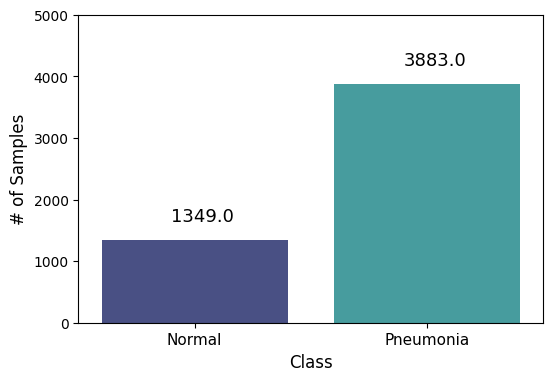

In [11]:
plt.figure(figsize=(6,4))

ax = sns.countplot(x='class', data=df_train, palette="mako")

plt.xlabel("Class", fontsize= 12)
plt.ylabel("# of Samples", fontsize= 12)
plt.ylim(0,5000)
plt.xticks([0,1], ['Normal', 'Pneumonia'], fontsize = 11)

for p in ax.patches:
    ax.annotate((p.get_height()), (p.get_x()+0.30, p.get_height()+300), fontsize = 13)
    
plt.show()

--- Data Distribution ---
class
Pneumonia    3883
Normal       1349
Name: count, dtype: int64
-------------------------


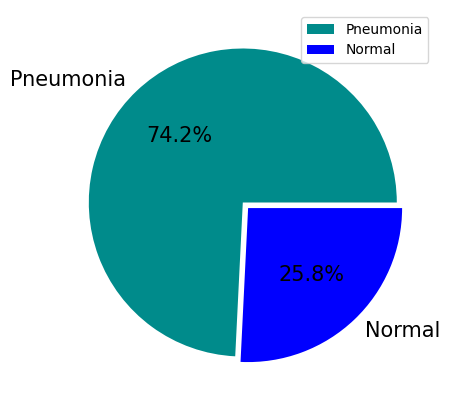

In [12]:
import matplotlib.pyplot as plt

# 1. مسح أي رسومات سابقة معلقة في الذاكرة لضمان نظافة المربع
plt.clf()
plt.close('all')

# 2. طباعة تكرار الفئات للتأكد من أن الجدول يحتوي على بيانات فعلاً
print("--- Data Distribution ---")
print(df_train['class'].value_counts())
print("-------------------------")

# 3. إعداد المخطط الجديد
plt.figure(figsize=(7,5))
counts = df_train['class'].value_counts()
actual_explode = [0, 0.05] if len(counts) == 2 else [0] * len(counts)

# 4. أمر الرسم المباشر
counts.plot(
    kind='pie',
    autopct='%1.1f%%', 
    colors=['darkcyan', 'blue'], 
    explode=actual_explode, 
    textprops={"fontsize":15},
    labels=counts.index
)

plt.legend(labels=counts.index, loc="upper right")
plt.ylabel('') 
plt.show()

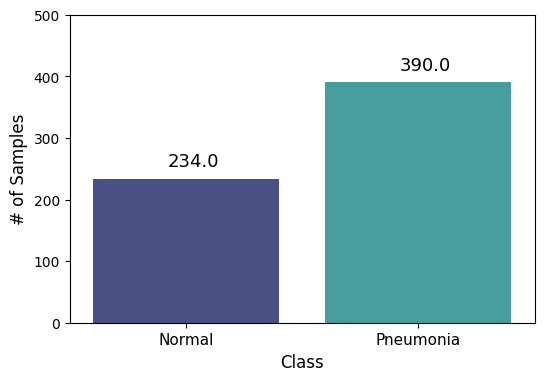

In [13]:
plt.figure(figsize=(6,4))

ax = sns.countplot(x='class', data=df_test, palette="mako")

plt.xlabel("Class", fontsize= 12)
plt.ylabel("# of Samples", fontsize= 12)
plt.ylim(0,500)
plt.xticks([0,1], ['Normal', 'Pneumonia'], fontsize = 11)

for p in ax.patches:
    ax.annotate((p.get_height()), (p.get_x()+0.32, p.get_height()+20), fontsize = 13)
    
plt.show()

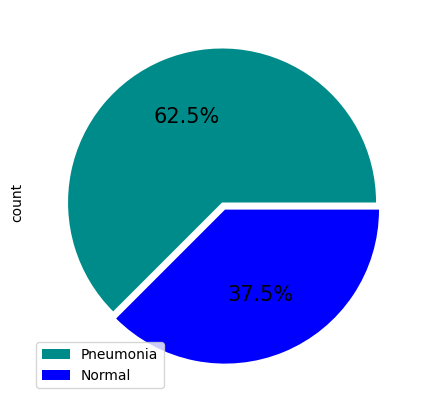

In [14]:
plt.figure(figsize=(7,5))

df_test['class'].value_counts().plot(kind='pie',labels = ['',''], autopct='%1.1f%%', colors = ['darkcyan','blue'], explode = [0,0.05], textprops = {"fontsize":15})

plt.legend(labels=['Pneumonia', 'Normal'])
plt.show()

The distributions from these datasets are a little different from each other. Both are slightly imbalanced, having more samples from the positive class (Pneumonia), with the training set being a little more imbalanced.

Before we move on to the next section, we will take a look at a few examples from each dataset.

Train Set - Normal


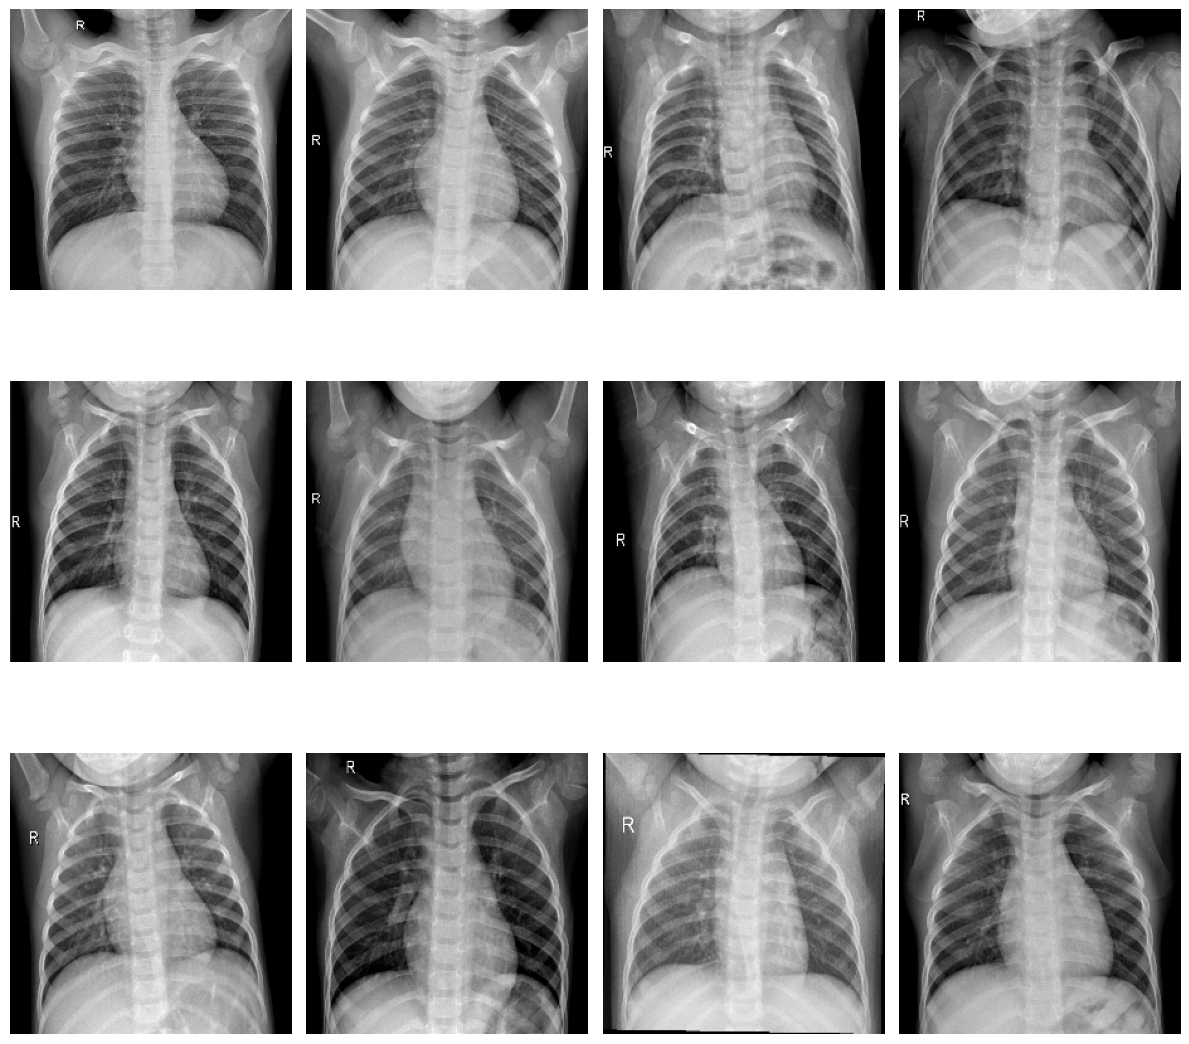

In [15]:
print('Train Set - Normal')

plt.figure(figsize=(12,12))

for i in range(0, 12):
    plt.subplot(3,4,i + 1)
    img = cv2.imread(train_normal[i])
    img = cv2.resize(img, (IMG_SIZE,IMG_SIZE))
    plt.imshow(img)
    plt.axis("off")

plt.tight_layout()

plt.show()

Train Set - Pneumonia


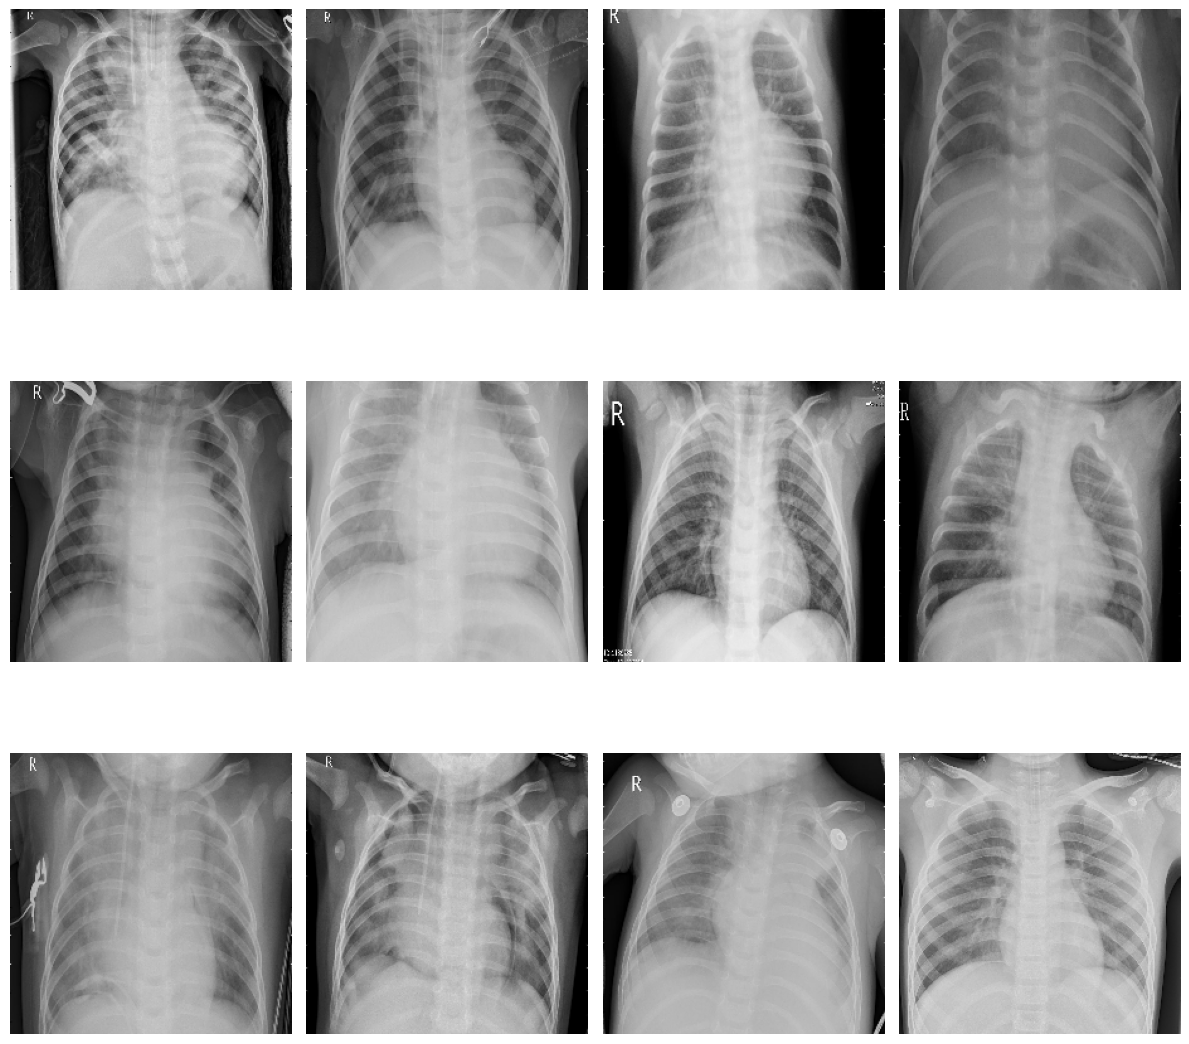

In [16]:
print('Train Set - Pneumonia')

plt.figure(figsize=(12,12))

for i in range(0, 12):
    plt.subplot(3,4,i + 1)
    img = cv2.imread(train_pneumonia[i])
    img = cv2.resize(img, (IMG_SIZE,IMG_SIZE))
    plt.imshow(img)
    plt.axis("off")

plt.tight_layout()

plt.show()

Test Set - Normal


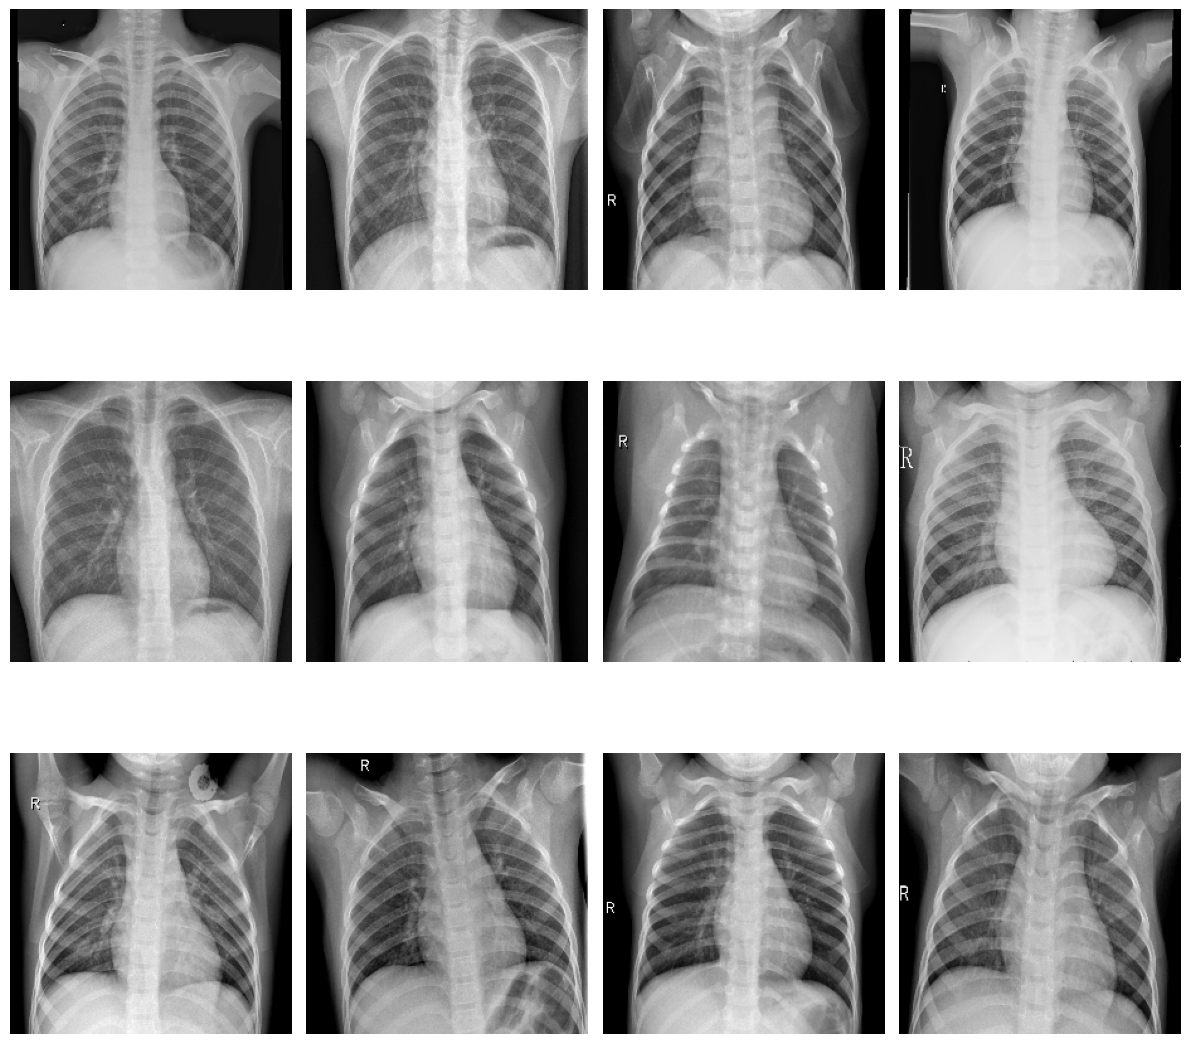

In [17]:
print('Test Set - Normal')

plt.figure(figsize=(12,12))

for i in range(0, 12):
    plt.subplot(3,4,i + 1)
    img = cv2.imread(test_normal[i])
    img = cv2.resize(img, (IMG_SIZE,IMG_SIZE))
    plt.imshow(img)
    plt.axis("off")

plt.tight_layout()

plt.show()

Test Set - Pneumonia


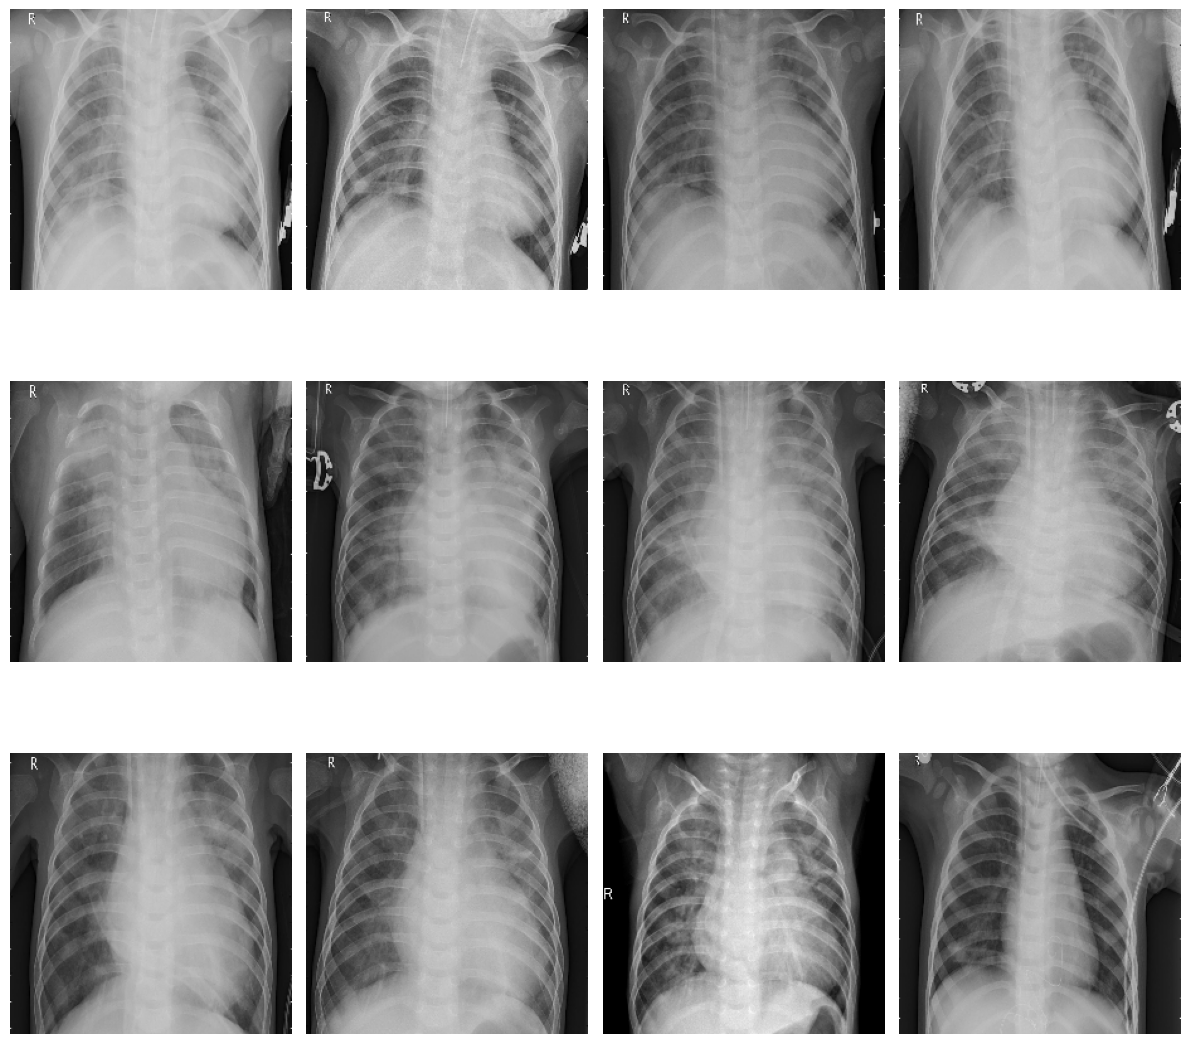

In [18]:
print('Test Set - Pneumonia')

plt.figure(figsize=(12,12))

for i in range(0, 12):
    plt.subplot(3,4,i + 1)
    img = cv2.imread(test_pneumonia[i])
    img = cv2.resize(img, (IMG_SIZE,IMG_SIZE))
    plt.imshow(img)
    plt.axis("off")

plt.tight_layout()

plt.show()

# <a id="4">Preparing the Data</a> 

First, we need to create a validation set. To do that, we apply a simple stratified split on the original train dataset, using 80% for actual training and 20% for validation purposes.

In [19]:
train_df, val_df = train_test_split(df_train, test_size = 0.20, random_state = SEED, stratify = df_train['class'])

In [20]:
train_df

,class,image
3566,Pneumonia,C:\Users\el_bostan\Desktop\X_Ray Image\chest_xray\train/PNEUMONIA\BACTERIA-8718799-0001.jpeg
2866,Pneumonia,C:\Users\el_bostan\Desktop\X_Ray Image\chest_xray\train/PNEUMONIA\BACTERIA-6295192-0003.jpeg
2681,Pneumonia,C:\Users\el_bostan\Desktop\X_Ray Image\chest_xray\train/PNEUMONIA\BACTERIA-5615122-0001.jpeg
1199,Normal,C:\Users\el_bostan\Desktop\X_Ray Image\chest_xray\train/NORMAL\NORMAL-9031828-0001.jpeg
4619,Pneumonia,C:\Users\el_bostan\Desktop\X_Ray Image\chest_xray\train/PNEUMONIA\VIRUS-5822550-0001.jpeg
...,...,...
3476,Pneumonia,C:\Users\el_bostan\Desktop\X_Ray Image\chest_xray\train/PNEUMONIA\BACTERIA-8467199-0001.jpeg
678,Normal,C:\Users\el_bostan\Desktop\X_Ray Image\chest_xray\train/NORMAL\NORMAL-5634312-0001.jpeg
1560,Pneumonia,C:\Users\el_bostan\Desktop\X_Ray Image\chest_xray\train/PNEUMONIA\BACTERIA-1797366-0001.jpeg
2769,Pneumonia,C:\Users\el_bostan\Desktop\X_Ray Image\chest_xray\train/PNEUMONIA\BACTERIA-5965088-0001.jpeg


In [21]:
val_df

,class,image
2945,Pneumonia,C:\Users\el_bostan\Desktop\X_Ray Image\chest_xray\train/PNEUMONIA\BACTERIA-654117-0001.jpeg
4878,Pneumonia,C:\Users\el_bostan\Desktop\X_Ray Image\chest_xray\train/PNEUMONIA\VIRUS-7603659-0001.jpeg
3177,Pneumonia,C:\Users\el_bostan\Desktop\X_Ray Image\chest_xray\train/PNEUMONIA\BACTERIA-7512869-0002.jpeg
972,Normal,C:\Users\el_bostan\Desktop\X_Ray Image\chest_xray\train/NORMAL\NORMAL-7436212-0002.jpeg
3059,Pneumonia,C:\Users\el_bostan\Desktop\X_Ray Image\chest_xray\train/PNEUMONIA\BACTERIA-7022864-0004.jpeg
...,...,...
253,Normal,C:\Users\el_bostan\Desktop\X_Ray Image\chest_xray\train/NORMAL\NORMAL-2699389-0002.jpeg
4315,Pneumonia,C:\Users\el_bostan\Desktop\X_Ray Image\chest_xray\train/PNEUMONIA\VIRUS-3896078-0002.jpeg
687,Normal,C:\Users\el_bostan\Desktop\X_Ray Image\chest_xray\train/NORMAL\NORMAL-566227-0001.jpeg
3417,Pneumonia,C:\Users\el_bostan\Desktop\X_Ray Image\chest_xray\train/PNEUMONIA\BACTERIA-8313249-0001.jpeg


Now, we’re going to load the images from the folders and prepare them to feed our models. 

We begin by defining the data generators. With Keras Image Data Generator, we can rescale the pixel values and apply random transformation techniques for data augmentation on the fly. We define two different generators. The val_datagen is used to simply rescale the validation and test sets. The train_datagen includes some transformations to augment the train set.

We apply those generators on each dataset using the flow_from_dataframe method. Apart from the transformations defined in each generator, the images are also resized based on the target_size set.

In [22]:
# https://vijayabhaskar96.medium.com/tutorial-on-keras-flow-from-dataframe-1fd4493d237c

train_datagen = ImageDataGenerator(rescale=1/255.,
                                  zoom_range = 0.1,
                                  #rotation_range = 0.1,
                                  width_shift_range = 0.1,
                                  height_shift_range = 0.1)

val_datagen = ImageDataGenerator(rescale=1/255.)

ds_train = train_datagen.flow_from_dataframe(train_df,
                                             #directory=train_path, #dataframe contains the full paths
                                             x_col = 'image',
                                             y_col = 'class',
                                             target_size = (IMG_SIZE, IMG_SIZE),
                                             class_mode = 'binary',
                                             batch_size = BATCH,
                                             seed = SEED)

ds_val = val_datagen.flow_from_dataframe(val_df,
                                            #directory=train_path,
                                            x_col = 'image',
                                            y_col = 'class',
                                            target_size = (IMG_SIZE, IMG_SIZE),
                                            class_mode = 'binary',
                                            batch_size = BATCH,
                                            seed = SEED)

ds_test = val_datagen.flow_from_dataframe(df_test,
                                            #directory=test_path,
                                            x_col = 'image',
                                            y_col = 'class',
                                            target_size = (IMG_SIZE, IMG_SIZE),
                                            class_mode = 'binary',
                                            batch_size = 1,
                                            shuffle = False)

Found 4185 validated image filenames belonging to 2 classes.
Found 1047 validated image filenames belonging to 2 classes.
Found 624 validated image filenames belonging to 2 classes.


Now, we are ready for the next stage: creating and training the image classification models.

# <a id="5">Custom CNN</a>

In [23]:
#Setting callbakcs

early_stopping = callbacks.EarlyStopping(
    monitor='val_loss',
    patience=5,
    min_delta=1e-7,
    restore_best_weights=True,
)

plateau = callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor = 0.2,                                     
    patience = 2,                                   
    min_delt = 1e-7,                                
    cooldown = 0,                               
    verbose = 1
) 

Let’s define our first model ‘from scratch’ and see how it performs.

In [24]:
def get_model():
    
    #Input shape = [width, height, color channels]
    inputs = layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
    
    # Block One
    x = layers.Conv2D(filters=16, kernel_size=3, padding='valid')(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.MaxPool2D()(x)
    x = layers.Dropout(0.2)(x)

    # Block Two
    x = layers.Conv2D(filters=32, kernel_size=3, padding='valid')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.MaxPool2D()(x)
    x = layers.Dropout(0.2)(x)
    
    # Block Three
    x = layers.Conv2D(filters=64, kernel_size=3, padding='valid')(x)
    x = layers.Conv2D(filters=64, kernel_size=3, padding='valid')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.MaxPool2D()(x)
    x = layers.Dropout(0.4)(x)

    # Head
    #x = layers.BatchNormalization()(x)
    x = layers.Flatten()(x)
    x = layers.Dense(64, activation='relu')(x)
    x = layers.Dropout(0.5)(x)
    
    #Final Layer (Output)
    output = layers.Dense(1, activation='sigmoid')(x)
    
    model = keras.Model(inputs=[inputs], outputs=output)
    
    return model

In [25]:
keras.backend.clear_session()

model = get_model()
model.compile(loss='binary_crossentropy'
              , optimizer = keras.optimizers.Adam(learning_rate=3e-5), metrics='binary_accuracy')

model.summary()



Model: "model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_1 (InputLayer)        [(None, 224, 224, 3)]     0         
                                                                 
 conv2d (Conv2D)             (None, 222, 222, 16)      448       
                                                                 
 batch_normalization (Batch  (None, 222, 222, 16)      64        
 Normalization)                                                  
                                                                 
 activation (Activation)     (None, 222, 222, 16)      0         
                                                                 
 max_pooling2d (MaxPooling2  (None, 111, 111, 16)      0         
 D)                                                              
                                                                 
 dropout (Dropout)           (None, 111, 111, 16)      0   

In [26]:
history = model.fit(ds_train,
          batch_size = BATCH, epochs = 10,
          validation_data=ds_val,
          callbacks=[early_stopping, plateau],
          steps_per_epoch=(len(train_df)/BATCH),
          validation_steps=(len(val_df)/BATCH));

Epoch 1/10


130/130 [==============================] - 192s 1s/step - loss: 0.4756 - binary_accuracy: 0.7859 - val_loss: 0.9782 - val_binary_accuracy: 0.7421 - lr: 3.0000e-05
Epoch 2/10
130/130 [==============================] - 177s 1s/step - loss: 0.3039 - binary_accuracy: 0.8671 - val_loss: 1.8914 - val_binary_accuracy: 0.7421 - lr: 3.0000e-05
Epoch 3/10
131/130 [==============================] - ETA: 0s - loss: 0.2562 - binary_accuracy: 0.8984
Epoch 3: ReduceLROnPlateau reducing learning rate to 5.9999998484272515e-06.
130/130 [==============================] - 178s 1s/step - loss: 0.2562 - binary_accuracy: 0.8984 - val_loss: 1.6763 - val_binary_accuracy: 0.7421 - lr: 3.0000e-05
Epoch 4/10
130/130 [==============================] - 178s 1s/step - loss: 0.2211 - binary_accuracy: 0.9102 - val_loss: 1.1150 - val_binary_accuracy: 0.7421 - lr: 6.0000e-06
Epoch 5/10
130/130 [==============================] - 181s 1s/step - loss: 0.2222 - binary_accuracy: 0.9114 - val_loss: 0.2543 - val_

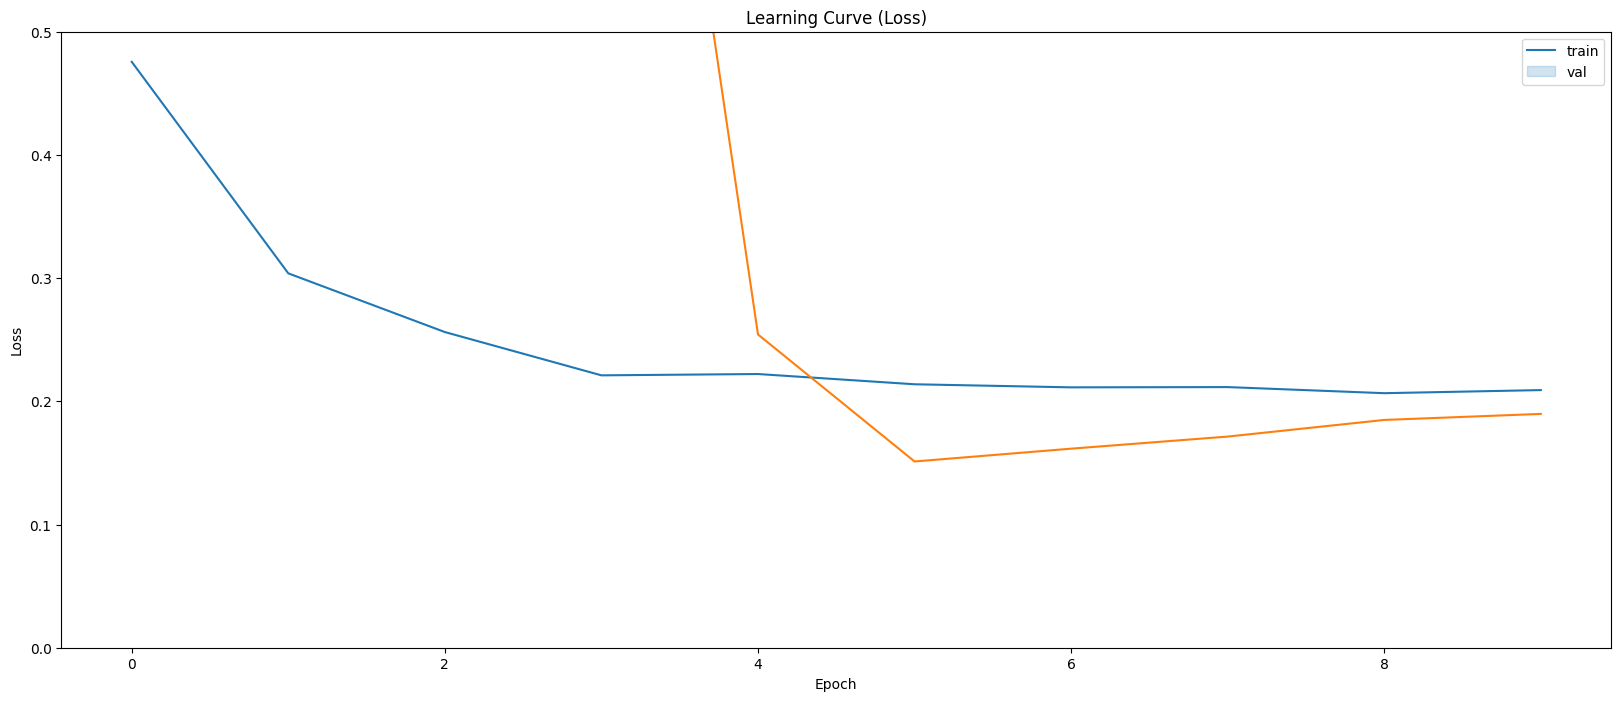

In [27]:
fig, ax = plt.subplots(figsize=(20,8))
sns.lineplot(x = history.epoch, y = history.history['loss'])
sns.lineplot(x = history.epoch, y = history.history['val_loss'])
ax.set_title('Learning Curve (Loss)')
ax.set_ylabel('Loss')
ax.set_xlabel('Epoch')
ax.set_ylim(0, 0.5)
ax.legend(['train', 'val'], loc='best')
plt.show()

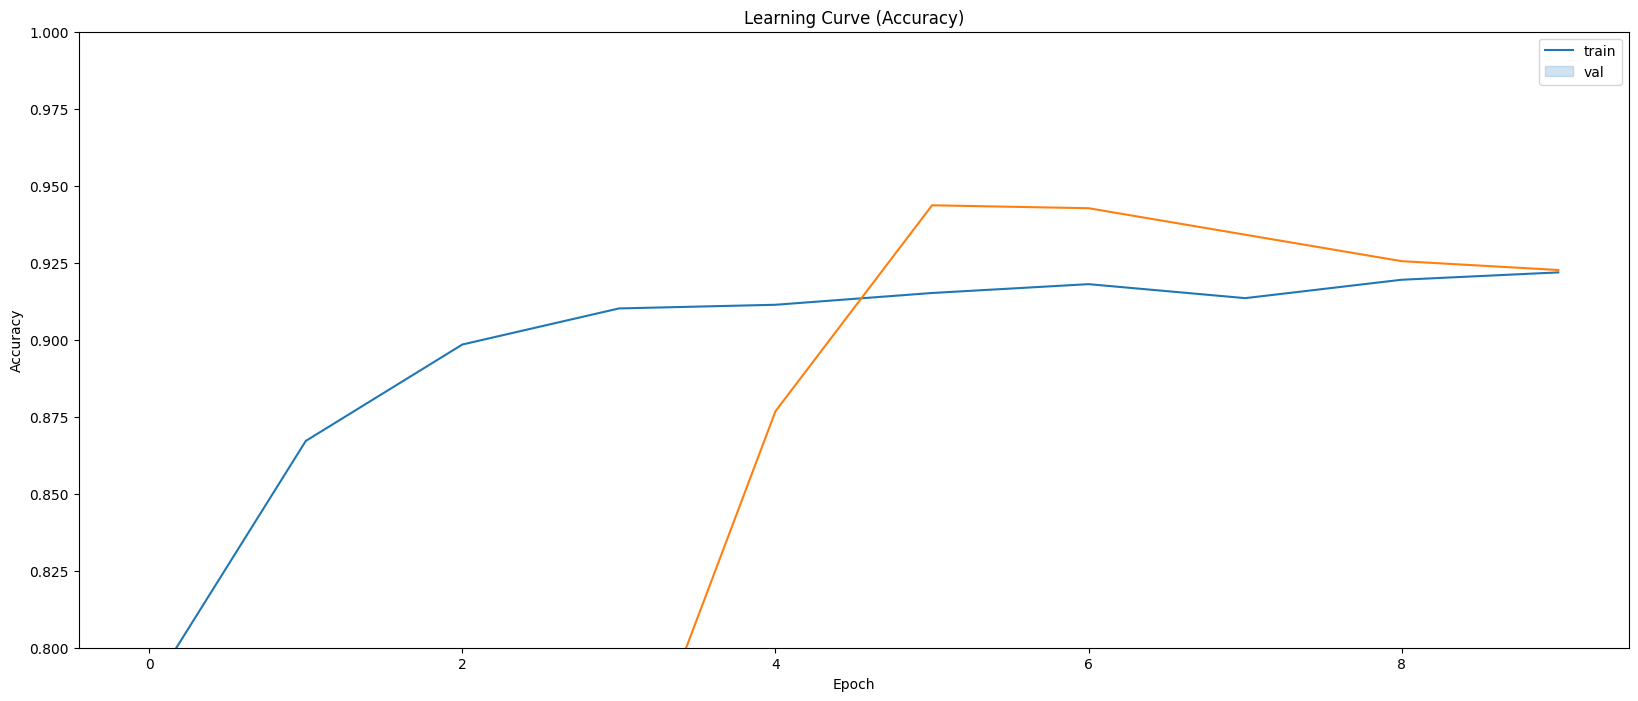

In [28]:
fig, ax = plt.subplots(figsize=(20,8))
sns.lineplot(x = history.epoch, y = history.history['binary_accuracy'])
sns.lineplot(x = history.epoch, y = history.history['val_binary_accuracy'])
ax.set_title('Learning Curve (Accuracy)')
ax.set_ylabel('Accuracy')
ax.set_xlabel('Epoch')
ax.set_ylim(0.80, 1.0)
ax.legend(['train', 'val'], loc='best')
plt.show()

In [30]:
score = model.evaluate(ds_test, steps = len(df_test), verbose = 0)

print('Test loss:', score[0])
print('Test accuracy:', score[1])

Test loss: 0.24215878546237946
Test accuracy: 0.8926281929016113


# <a id="6">Transfer Learning</a> 

The second approach, called transfer learning, consists of using a pretrained model as a feature extractor. In this notebook, the selected model was the ResNet152V2 available on the Keras Package [(link)](https://keras.io/api/applications/resnet/#resnet152v2-function). 

This model was already trained in another dataset (ImageNet). What we do here is to set include_top to false, removing the ‘head’, responsible for assigning the classes in this other dataset, and keep all the previous layers. Then, we include our last few layers, including the one responsible for generating the output.



In [31]:
base_model = tf.keras.applications.ResNet152V2(
    weights='imagenet',
    input_shape=(IMG_SIZE, IMG_SIZE, 3),
    include_top=False)

base_model.trainable = False

def get_pretrained():
    
    #Input shape = [width, height, color channels]
    inputs = layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
    
    x = base_model(inputs)

    # Head
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(128, activation='relu')(x)
    x = layers.Dropout(0.1)(x)
    
    #Final Layer (Output)
    output = layers.Dense(1, activation='sigmoid')(x)
    
    model = keras.Model(inputs=[inputs], outputs=output)
    
    return model

In [32]:
keras.backend.clear_session()

model_pretrained = get_pretrained()
model_pretrained.compile(loss='binary_crossentropy'
              , optimizer = keras.optimizers.Adam(learning_rate=5e-5), metrics='binary_accuracy')

model_pretrained.summary()

Model: "model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_1 (InputLayer)        [(None, 224, 224, 3)]     0         
                                                                 
 resnet152v2 (Functional)    (None, 7, 7, 2048)        58331648  
                                                                 
 global_average_pooling2d (  (None, 2048)              0         
 GlobalAveragePooling2D)                                         
                                                                 
 dense (Dense)               (None, 128)               262272    
                                                                 
 dropout (Dropout)           (None, 128)               0         
                                                                 
 dense_1 (Dense)             (None, 1)                 129       
                                                             

In [33]:
history = model_pretrained.fit(ds_train,
          batch_size = BATCH, epochs = 10,
          validation_data=ds_val,
          callbacks=[early_stopping, plateau],
          steps_per_epoch=(len(train_df)/BATCH),
          validation_steps=(len(val_df)/BATCH));

Epoch 1/10
130/130 [==============================] - 507s 4s/step - loss: 0.3658 - binary_accuracy: 0.8358 - val_loss: 0.2141 - val_binary_accuracy: 0.9236 - lr: 5.0000e-05
Epoch 2/10
130/130 [==============================] - 489s 4s/step - loss: 0.1930 - binary_accuracy: 0.9343 - val_loss: 0.1595 - val_binary_accuracy: 0.9398 - lr: 5.0000e-05
Epoch 3/10
130/130 [==============================] - 529s 4s/step - loss: 0.1591 - binary_accuracy: 0.9422 - val_loss: 0.1487 - val_binary_accuracy: 0.9427 - lr: 5.0000e-05
Epoch 4/10
130/130 [==============================] - 545s 4s/step - loss: 0.1440 - binary_accuracy: 0.9486 - val_loss: 0.1262 - val_binary_accuracy: 0.9503 - lr: 5.0000e-05
Epoch 5/10
130/130 [==============================] - 504s 4s/step - loss: 0.1336 - binary_accuracy: 0.9486 - val_loss: 0.1224 - val_binary_accuracy: 0.9570 - lr: 5.0000e-05
Epoch 6/10
130/130 [==============================] - 501s 4s/step - loss: 0.1335 - binary_accuracy: 0.9489 - val_loss: 0.1150 - v

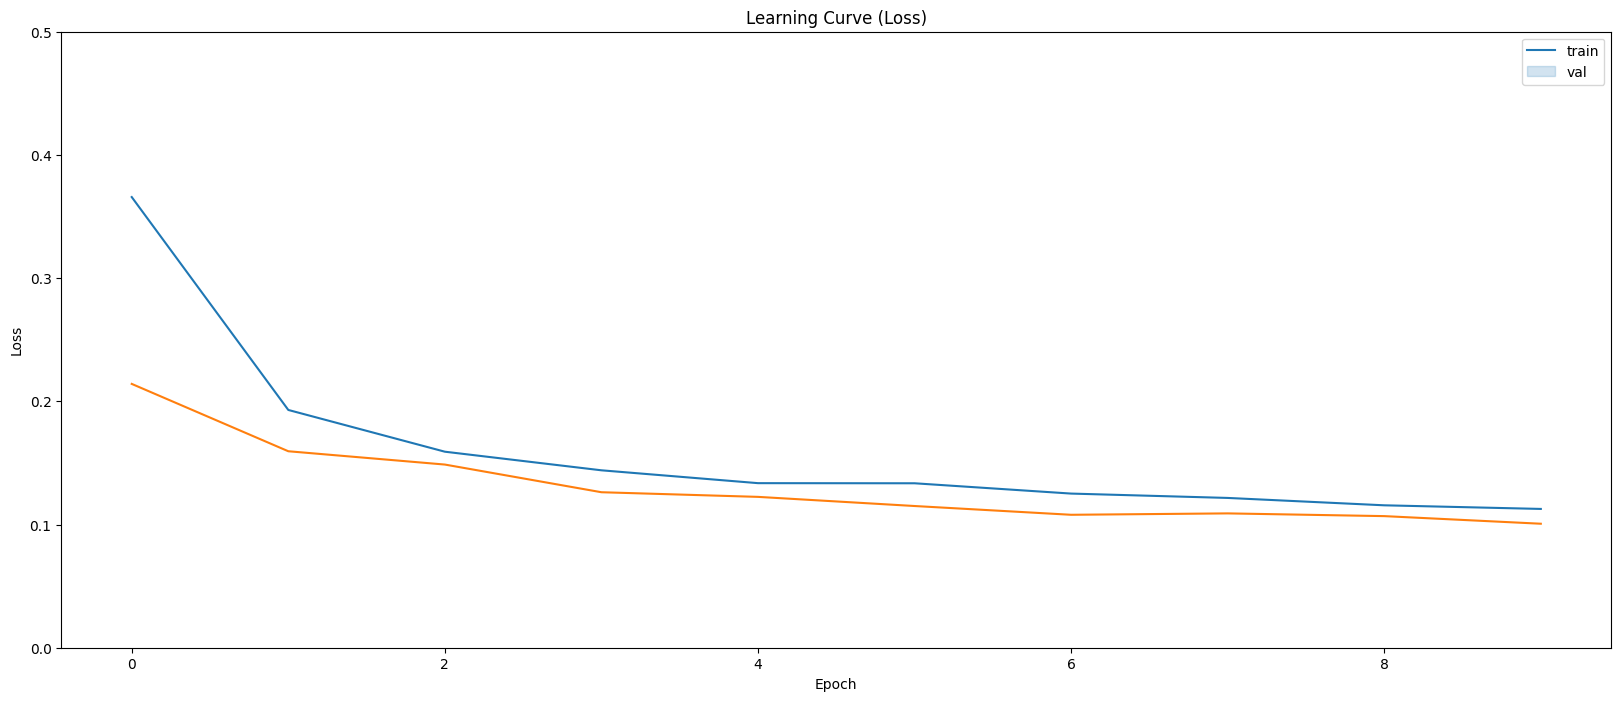

In [34]:
fig, ax = plt.subplots(figsize=(20,8))
sns.lineplot(x = history.epoch, y = history.history['loss'])
sns.lineplot(x = history.epoch, y = history.history['val_loss'])
ax.set_title('Learning Curve (Loss)')
ax.set_ylabel('Loss')
ax.set_xlabel('Epoch')
ax.set_ylim(0, 0.5)
ax.legend(['train', 'val'], loc='best')
plt.show()

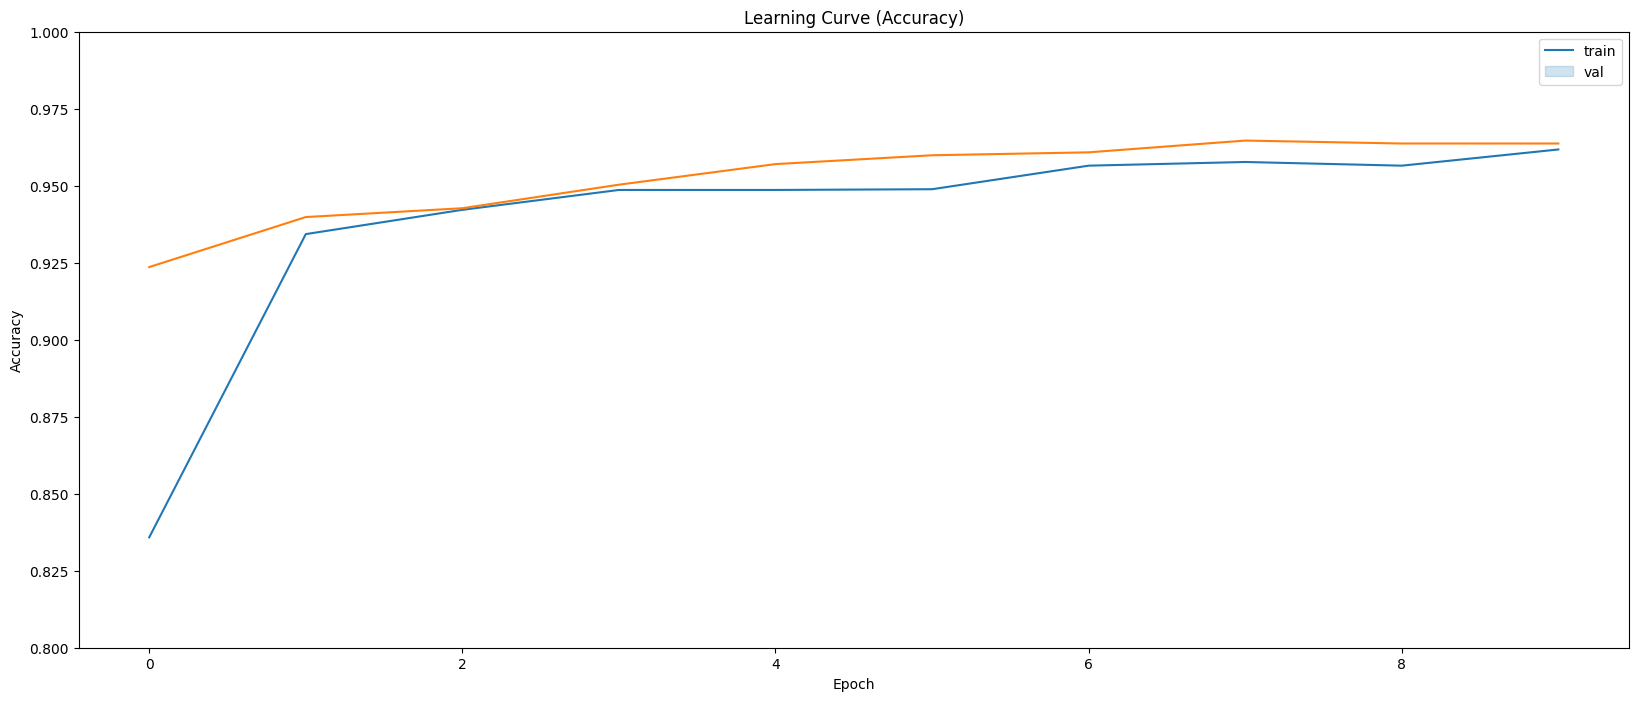

In [35]:
fig, ax = plt.subplots(figsize=(20,8))
sns.lineplot(x = history.epoch, y = history.history['binary_accuracy'])
sns.lineplot(x = history.epoch, y = history.history['val_binary_accuracy'])
ax.set_title('Learning Curve (Accuracy)')
ax.set_ylabel('Accuracy')
ax.set_xlabel('Epoch')
ax.set_ylim(0.80, 1.0)
ax.legend(['train', 'val'], loc='best')
plt.show()

In [36]:
score = model_pretrained.evaluate(ds_val, steps = len(val_df)/BATCH, verbose = 0)
print('Val loss:', score[0])
print('Val accuracy:', score[1])

Val loss: 0.10064229369163513
Val accuracy: 0.963705837726593


In [37]:
score = model_pretrained.evaluate(ds_test, steps = len(df_test), verbose = 0)
print('Test loss:', score[0])
print('Test accuracy:', score[1])

Test loss: 0.2821636199951172
Test accuracy: 0.8846153616905212


# <a id="7">Fine Tuning</a> 

Our last approach is called Fine Tuning. In the last section, all the layers from the pretrained model were ‘frozen’, preserving the weights calculated during its training on the ImageNet dataset. Now, we are going to unfreeze a few of its last layers and continue the training, tuning the weights from these layers according to our dataset.

In [38]:
base_model.trainable = True

# Freeze all layers except for the
for layer in base_model.layers[:-13]:
    layer.trainable = False

In [39]:
# Check which layers are tuneable (trainable)
for layer_number, layer in enumerate(base_model.layers):
    print(layer_number, layer.name, layer.trainable)

0 input_2 False
1 conv1_pad False
2 conv1_conv False
3 pool1_pad False
4 pool1_pool False
5 conv2_block1_preact_bn False
6 conv2_block1_preact_relu False
7 conv2_block1_1_conv False
8 conv2_block1_1_bn False
9 conv2_block1_1_relu False
10 conv2_block1_2_pad False
11 conv2_block1_2_conv False
12 conv2_block1_2_bn False
13 conv2_block1_2_relu False
14 conv2_block1_0_conv False
15 conv2_block1_3_conv False
16 conv2_block1_out False
17 conv2_block2_preact_bn False
18 conv2_block2_preact_relu False
19 conv2_block2_1_conv False
20 conv2_block2_1_bn False
21 conv2_block2_1_relu False
22 conv2_block2_2_pad False
23 conv2_block2_2_conv False
24 conv2_block2_2_bn False
25 conv2_block2_2_relu False
26 conv2_block2_3_conv False
27 conv2_block2_out False
28 conv2_block3_preact_bn False
29 conv2_block3_preact_relu False
30 conv2_block3_1_conv False
31 conv2_block3_1_bn False
32 conv2_block3_1_relu False
33 conv2_block3_2_pad False
34 conv2_block3_2_conv False
35 conv2_block3_2_bn False
36 conv2_bloc

In [40]:
model_pretrained.compile(loss='binary_crossentropy'
              , optimizer = keras.optimizers.Adam(learning_rate=2e-6), metrics='binary_accuracy')

model_pretrained.summary()

Model: "model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_1 (InputLayer)        [(None, 224, 224, 3)]     0         
                                                                 
 resnet152v2 (Functional)    (None, 7, 7, 2048)        58331648  
                                                                 
 global_average_pooling2d (  (None, 2048)              0         
 GlobalAveragePooling2D)                                         
                                                                 
 dense (Dense)               (None, 128)               262272    
                                                                 
 dropout (Dropout)           (None, 128)               0         
                                                                 
 dense_1 (Dense)             (None, 1)                 129       
                                                             

In [43]:
history = model_pretrained.fit(ds_train,
          batch_size = BATCH, epochs = 10,
          validation_data=ds_val,
          callbacks=[early_stopping, plateau],
          steps_per_epoch=(len(train_df)/BATCH),
          validation_steps=(len(val_df)/BATCH));

Epoch 1/10
130/130 [==============================] - 514s 4s/step - loss: 0.2143 - binary_accuracy: 0.9121 - val_loss: 0.1752 - val_binary_accuracy: 0.9427 - lr: 2.0000e-06
Epoch 2/10
130/130 [==============================] - 508s 4s/step - loss: 0.1718 - binary_accuracy: 0.9472 - val_loss: 0.1540 - val_binary_accuracy: 0.9542 - lr: 2.0000e-06
Epoch 3/10
130/130 [==============================] - 511s 4s/step - loss: 0.1512 - binary_accuracy: 0.9472 - val_loss: 0.1372 - val_binary_accuracy: 0.9532 - lr: 2.0000e-06
Epoch 4/10
130/130 [==============================] - 552s 4s/step - loss: 0.1430 - binary_accuracy: 0.9524 - val_loss: 0.1293 - val_binary_accuracy: 0.9551 - lr: 2.0000e-06
Epoch 5/10
130/130 [==============================] - 702s 5s/step - loss: 0.1409 - binary_accuracy: 0.9539 - val_loss: 0.1252 - val_binary_accuracy: 0.9570 - lr: 2.0000e-06
Epoch 6/10
130/130 [==============================] - 760s 6s/step - loss: 0.1337 - binary_accuracy: 0.9532 - val_loss: 0.1206 - v

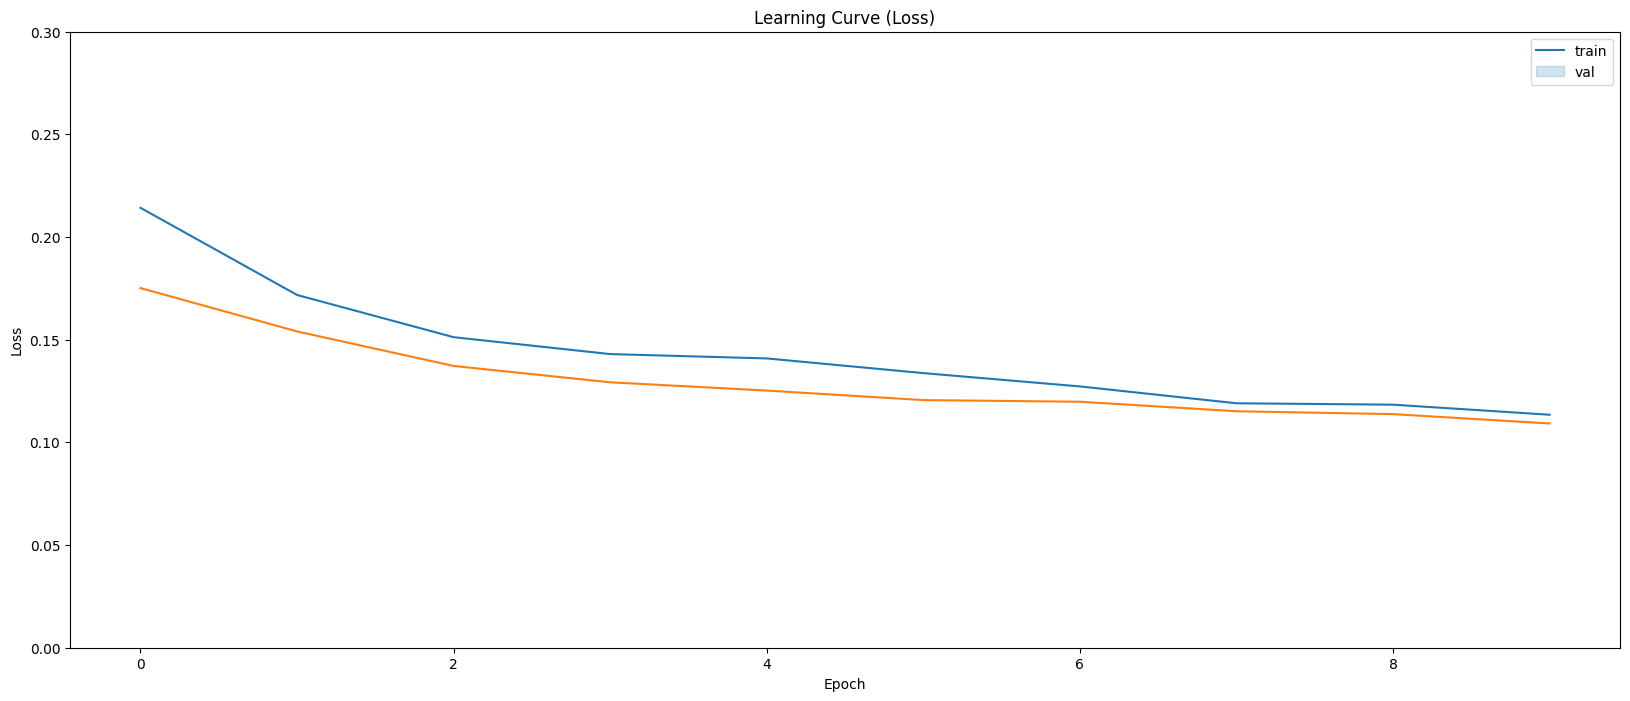

In [44]:
fig, ax = plt.subplots(figsize=(20,8))
sns.lineplot(x = history.epoch, y = history.history['loss'])
sns.lineplot(x = history.epoch, y = history.history['val_loss'])
ax.set_title('Learning Curve (Loss)')
ax.set_ylabel('Loss')
ax.set_xlabel('Epoch')
ax.set_ylim(0, 0.3)
ax.legend(['train', 'val'], loc='best')
plt.show()

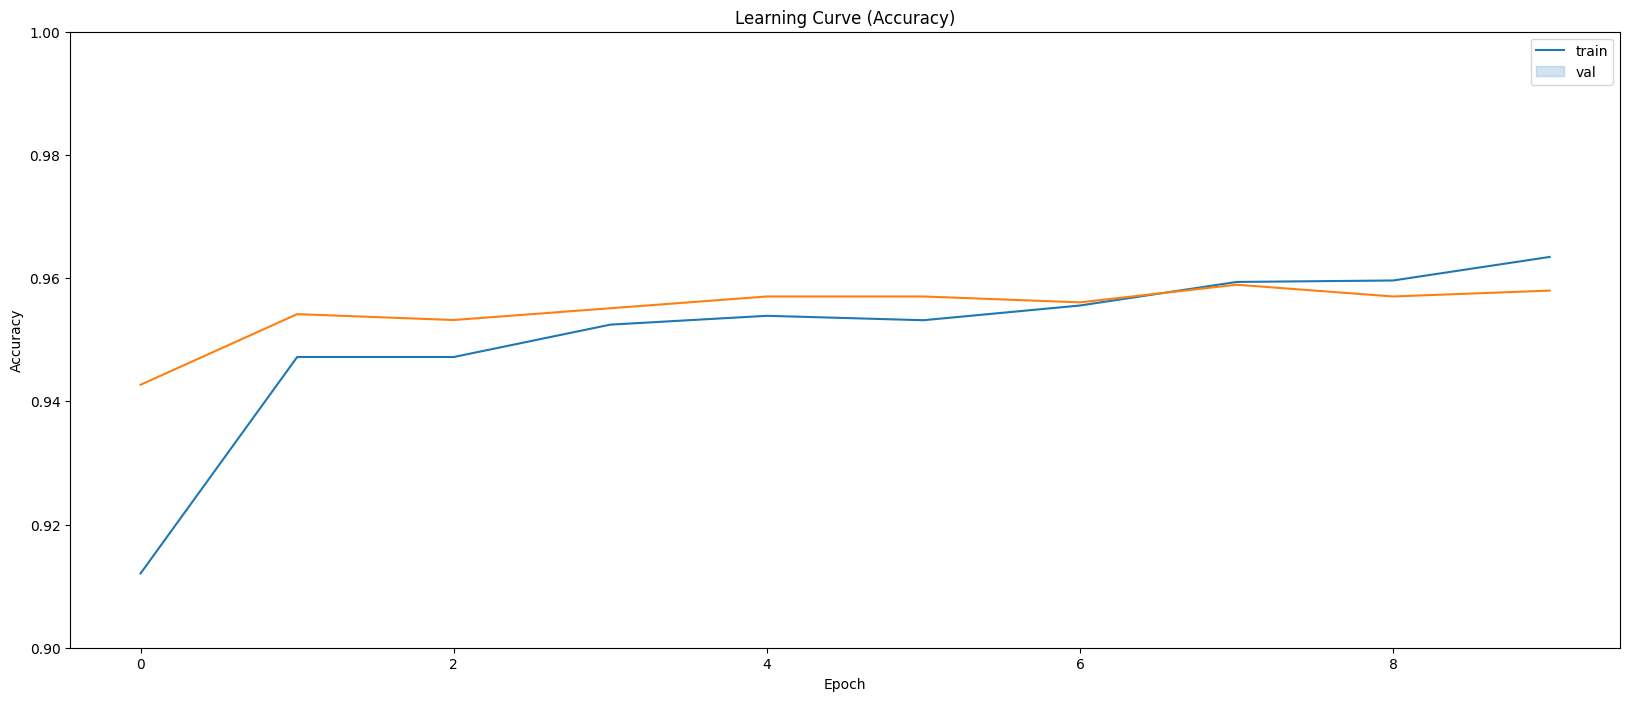

In [45]:
fig, ax = plt.subplots(figsize=(20,8))
sns.lineplot(x = history.epoch, y = history.history['binary_accuracy'])
sns.lineplot(x = history.epoch, y = history.history['val_binary_accuracy'])
ax.set_title('Learning Curve (Accuracy)')
ax.set_ylabel('Accuracy')
ax.set_xlabel('Epoch')
ax.set_ylim(0.90, 1.0)
ax.legend(['train', 'val'], loc='best')
plt.show()

In [46]:
score = model_pretrained.evaluate(ds_val, steps = len(val_df)/BATCH, verbose = 0)
print('Val loss:', score[0])
print('Val accuracy:', score[1])

Val loss: 0.10920996218919754
Val accuracy: 0.9579751491546631


In [47]:
score = model_pretrained.evaluate(ds_test, steps = len(df_test), verbose = 0)
print('Test loss:', score[0])
print('Test accuracy:', score[1])

Test loss: 0.24087588489055634
Test accuracy: 0.9070512652397156


As expected, the fine-tuning approach has reached the best score. We end this notebook by showing a few performance metrics.

# <a id="8">Performance Metrics</a> 

In [48]:
num_label = {'Normal': 0, 'Pneumonia' : 1}
Y_test = df_test['class'].copy().map(num_label).astype('int')

In [49]:
ds_test.reset()
predictions = model_pretrained.predict(ds_test, steps=len(ds_test), verbose=0)
pred_labels= np.where(predictions>0.5, 1, 0)

In [50]:
print("Test Accuracy: ", accuracy_score(Y_test, pred_labels))

Test Accuracy:  0.907051282051282


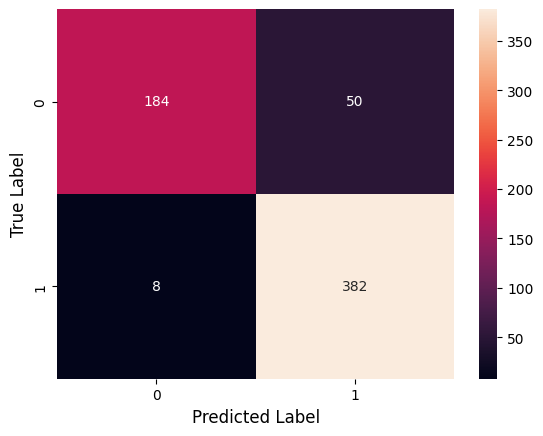

In [51]:
confusion_matrix = metrics.confusion_matrix(Y_test, pred_labels)
sns.heatmap(confusion_matrix, annot=True, fmt="d")

plt.xlabel("Predicted Label", fontsize= 12)
plt.ylabel("True Label", fontsize= 12)

plt.show()

In [52]:
print(metrics.classification_report(Y_test, pred_labels, labels = [0, 1]))

              precision    recall  f1-score   support

           0       0.96      0.79      0.86       234
           1       0.88      0.98      0.93       390

    accuracy                           0.91       624
   macro avg       0.92      0.88      0.90       624
weighted avg       0.91      0.91      0.90       624



ROC_AUC:  0.9717948717948718


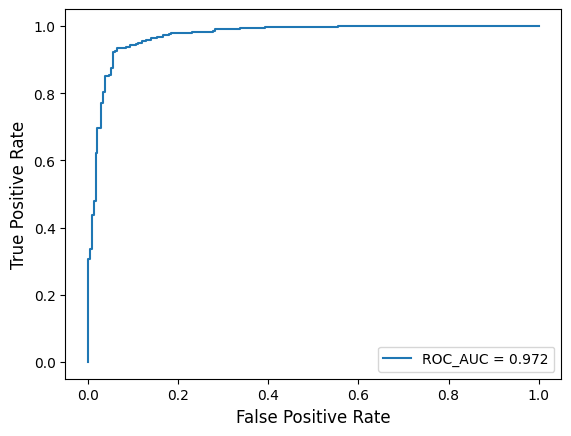

In [53]:
roc_auc = metrics.roc_auc_score(Y_test, predictions)
print('ROC_AUC: ', roc_auc)

fpr, tpr, thresholds = metrics.roc_curve(Y_test, predictions)

plt.plot(fpr, tpr, label = 'ROC_AUC = %0.3f' % roc_auc)

plt.xlabel("False Positive Rate", fontsize= 12)
plt.ylabel("True Positive Rate", fontsize= 12)
plt.legend(loc="lower right")

plt.show()

In [54]:
import os
os.makedirs("model", exist_ok=True)
model_pretrained.save("model/chest_xray_model.h5")